# Week 6 – Day 4

# Rolling Statistics and Smoothing Techniques

**Name:** Mohit Singh

## Objective

The objective of this notebook is to study rolling statistics and smoothing methods for financial time series.

Tasks performed:

- Calculate daily returns
- Plot 30-day rolling mean
- Plot 30-day rolling standard deviation
- Compare Simple Moving Average (SMA) and Exponential Weighted Moving Average (EWMA)
- Interpret the differences between the two smoothing techniques

In [8]:
# Import required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import yfinance as yf

## 1. Download Historical Data

In [9]:
# Download Reliance stock data
reliance = yf.download(
    "RELIANCE.NS",
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)

# Display first few rows
reliance.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-01,672.216187,680.008852,670.390532,675.956671,14004468
2020-01-02,683.660278,686.176208,673.284921,673.284921,17710316
2020-01-03,684.484009,686.487835,678.183067,682.636001,20984698
2020-01-06,668.609253,680.364982,667.050708,676.847198,24519177
2020-01-07,678.895630,683.304036,673.952826,676.401934,16683622


## 2. Calculate Daily Returns

In [10]:
# Calculate daily percentage returns
reliance["Returns"] = reliance["Close"].pct_change(fill_method=None)

# Remove missing values
returns = reliance["Returns"].dropna()

returns.head()

Date
2020-01-02    0.017024
2020-01-03    0.001205
2020-01-06   -0.023192
2020-01-07    0.015385
2020-01-08   -0.007510
Name: Returns, dtype: float64

## 3. Calculate Rolling Mean and Rolling Standard Deviation

In [11]:
# Calculate 30-day rolling mean of returns
rolling_mean = returns.rolling(window=30).mean()

# Calculate 30-day rolling standard deviation of returns
rolling_std = returns.rolling(window=30).std()

## 4. Plot Rolling Mean and Rolling Standard Deviation

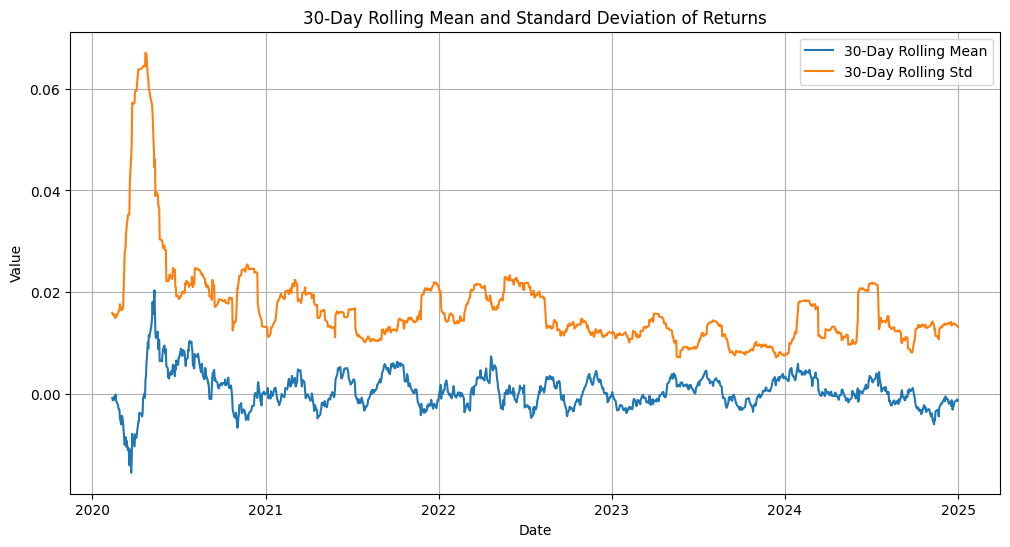

In [12]:
plt.figure(figsize=(12,6))

# Plot rolling mean
plt.plot(
    rolling_mean.index,
    rolling_mean,
    label="30-Day Rolling Mean"
)

# Plot rolling standard deviation
plt.plot(
    rolling_std.index,
    rolling_std,
    label="30-Day Rolling Std"
)

plt.title("30-Day Rolling Mean and Standard Deviation of Returns")
plt.xlabel("Date")
plt.ylabel("Value")

plt.legend()
plt.grid(True)

plt.savefig(
    "../images/rolling_mean_std.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Calculate SMA and EWMA

In [13]:
# Calculate 30-day Simple Moving Average (SMA)
reliance["SMA_30"] = reliance["Close"].rolling(window=30).mean()

# Calculate Exponential Weighted Moving Average (EWMA)
reliance["EWMA_30"] = reliance["Close"].ewm(span=30, adjust=False).mean()

## 6. Compare SMA and EWMA

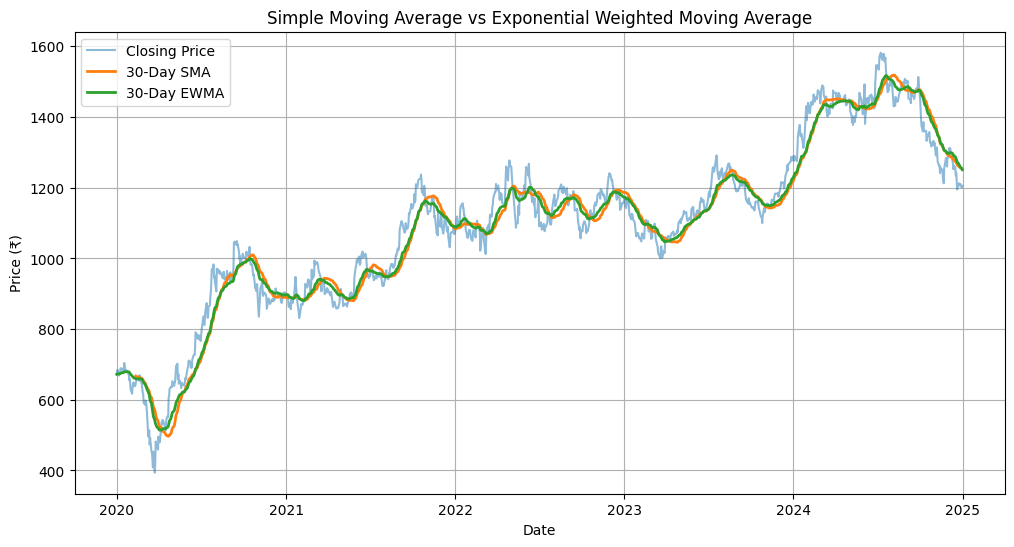

In [14]:
plt.figure(figsize=(12,6))

# Plot closing price
plt.plot(
    reliance.index,
    reliance["Close"],
    alpha=0.5,
    label="Closing Price"
)

# Plot SMA
plt.plot(
    reliance.index,
    reliance["SMA_30"],
    linewidth=2,
    label="30-Day SMA"
)

# Plot EWMA
plt.plot(
    reliance.index,
    reliance["EWMA_30"],
    linewidth=2,
    label="30-Day EWMA"
)

plt.title("Simple Moving Average vs Exponential Weighted Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (₹)")

plt.legend()
plt.grid(True)

plt.savefig(
    "../images/sma_vs_ewma.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Comparison: SMA vs EWMA

### Simple Moving Average (SMA)

- Assigns equal weight to all observations within the selected window.
- Responds more slowly to sudden price changes.
- Produces a smoother curve.

### Exponential Weighted Moving Average (EWMA)

- Assigns greater weight to recent observations.
- Responds more quickly to market movements.
- Is widely used in technical analysis and financial forecasting because it adapts faster to new information.

# Conclusion

The rolling mean and rolling standard deviation helped visualize changes in the average return and volatility over time.

The comparison between the Simple Moving Average (SMA) and the Exponential Weighted Moving Average (EWMA) showed that EWMA reacts more quickly to recent price changes because it assigns greater weight to newer observations. In contrast, SMA treats all observations equally within the rolling window, making it smoother but slower to respond.

Both methods are valuable, with SMA being useful for identifying long-term trends and EWMA being better suited for capturing recent market dynamics.